In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [48]:
import pandas as pd

df = pd.read_csv("../data/Churn data.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/Churn data.csv'

In [ ]:
import os

print("Current folder:")
print(os.getcwd())

In [ ]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if "Churn" in file:
            print(os.path.join(root, file))

In [ ]:
import os
print(os.getcwd())

In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sivaramakrishnan\Customer-Churn-Prediction\data\Churn data.csv")

df.head()

In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sivaramakrishnan\Customer-Churn-Prediction\data\Churn data.csv")

print("Shape:", df.shape)
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
print(df["Churn"].value_counts())

In [ ]:
df.describe()

In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

df.head()

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
import joblib

joblib.dump(model, "../models/churn_model.pkl")

In [ ]:
import joblib

joblib.dump(
    model,
    r"C:\Users\Sivaramakrishnan\Customer-Churn-Prediction\models\churn_model.pkl"
)

In [ ]:
import os

print(os.path.exists(
    r"C:\Users\Sivaramakrishnan\Customer-Churn-Prediction\models\churn_model.pkl"
))

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

In [ ]:
plt.figure(figsize=(10,5))
plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)
plt.title("Top 10 Important Features")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, ":", accuracy_score(y_test, pred))

In [ ]:
from sklearn.linear_model import LogisticRegression
import joblib

best_model = LogisticRegression(max_iter=1000)

best_model.fit(X_train, y_train)

joblib.dump(
    best_model,
    r"C:\Users\Sivaramakrishnan\Customer-Churn-Prediction\models\best_churn_model.pkl"
)

In [ ]:
import os
print(os.getcwd())

In [1]:
import os
print(os.getcwd())

C:\Users\Sivaramakrishnan


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sivaramakrishnan\Customer-Churn-Prediction\data\Churn data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7043, 20)
y Shape: (7043,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5634, 20)
(1409, 20)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

ValueError: could not convert string to float: '4223-BKEOR'

In [8]:
print(X.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
dtype: object


In [9]:
df = df.drop("customerID", axis=1)

In [10]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

ValueError: could not convert string to float: 'Female'

In [13]:
print(df.dtypes[df.dtypes == 'object'])

gender              object
Partner             object
Dependents          object
PhoneService        object
MultipleLines       object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
Contract            object
PaperlessBilling    object
PaymentMethod       object
TotalCharges        object
Churn               object
dtype: object


In [14]:
df = df.drop("customerID", axis=1)

KeyError: "['customerID'] not found in axis"

In [15]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [17]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [18]:
df = pd.get_dummies(df, drop_first=True)

In [19]:
print(df.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')


In [20]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8218594748048261


C:\Users\Sivaramakrishnan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

pred = lr.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8197303051809794


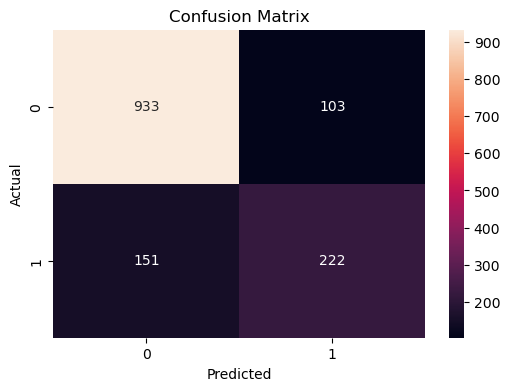

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [26]:
import joblib

joblib.dump(lr, "../models/best_churn_model.pkl")

print("Model saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '../models/best_churn_model.pkl'

In [27]:
import os
print(os.getcwd())

C:\Users\Sivaramakrishnan


In [28]:
import joblib

joblib.dump(
    lr,
    r"C:\Users\Sivaramakrishnan\Customer-Churn-Prediction\models\best_churn_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [29]:
# Customer Lifetime Value

df["CLV"] = df["MonthlyCharges"] * df["tenure"]

# Revenue loss if customer churns
df["RevenueLoss"] = df["CLV"]

# High risk customers
high_risk = df[df["Churn"] == "Yes"]

print("Total Revenue At Risk: ₹",
      round(high_risk["RevenueLoss"].sum(),2))

KeyError: 'Churn'

In [30]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sivaramakrishnan\Documents\Churn data.csv")

In [31]:
print("Churn" in df.columns)

True


In [32]:
df["CLV"] = df["MonthlyCharges"] * pd.to_numeric(df["tenure"])

high_risk = df[df["Churn"] == "Yes"]

print("Total Revenue At Risk: ₹",
      round(high_risk["CLV"].sum(), 2))

Total Revenue At Risk: ₹ 2862576.9


In [33]:
prob = lr.predict_proba(customer)

print("Churn Risk:",
      round(prob[0][1]*100,2),"%")

NameError: name 'customer' is not defined

In [34]:
customer = X_test.iloc[[0]]

In [35]:
prob = lr.predict_proba(customer)

print("Churn Risk:", round(prob[0][1] * 100, 2), "%")

Churn Risk: 6.27 %


C:\Users\Sivaramakrishnan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [36]:
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

C:\Users\Sivaramakrishnan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [37]:
prob = lr.predict_proba(customer)

print("Churn Risk:", round(prob[0][1] * 100, 2), "%")

Churn Risk: 69.75 %


In [38]:
df_original = pd.read_csv(r"C:\Users\Sivaramakrishnan\Documents\Churn data.csv")

df_original["CLV"] = (
    df_original["MonthlyCharges"] *
    df_original["tenure"]
)

print(df_original[["MonthlyCharges","tenure","CLV"]].head())

   MonthlyCharges  tenure      CLV
0           29.85       1    29.85
1           56.95      34  1936.30
2           53.85       2   107.70
3           42.30      45  1903.50
4           70.70       2   141.40


In [39]:
import pandas as pd

df_original = pd.read_csv(r"C:\Users\Sivaramakrishnan\Documents\Churn data.csv")

df_original["TotalCharges"] = pd.to_numeric(
    df_original["TotalCharges"],
    errors="coerce"
)

df_original["CLV"] = (
    df_original["MonthlyCharges"] *
    df_original["tenure"]
)

df_original[["MonthlyCharges", "tenure", "CLV"]].head()

,MonthlyCharges,tenure,CLV
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


In [40]:
high_risk_customers = df_original[
    df_original["Churn"] == "Yes"
]

total_revenue_risk = high_risk_customers["CLV"].sum()

print("Total Revenue At Risk: ₹",
      round(total_revenue_risk, 2))

Total Revenue At Risk: ₹ 2862576.9


In [41]:
customer_index = X_test.index[0]

customer_data = df_original.loc[customer_index]

revenue_loss = (
    customer_data["MonthlyCharges"] *
    customer_data["tenure"]
)

print(
    f"If this customer churns, company loses ₹{revenue_loss:.2f}"
)

If this customer churns, company loses ₹24.80


In [42]:
risk = prob[0][1] * 100

print("="*40)

print(f"Churn Risk: {risk:.2f}%")

print(f"Revenue At Risk: ₹{revenue_loss:.2f}")

if risk > 70:
    print("Recommended Action: Offer Discount")
elif risk > 40:
    print("Recommended Action: Contact Customer")
else:
    print("Recommended Action: No Action Needed")

print("="*40)

Churn Risk: 69.75%
Revenue At Risk: ₹24.80
Recommended Action: Contact Customer


In [43]:
def retention_simulator(risk):

    print("Current Churn Risk:", round(risk,2), "%")

    # Simulate retention offers
    discount_risk = max(risk - 25, 0)
    premium_support_risk = max(risk - 15, 0)
    loyalty_program_risk = max(risk - 10, 0)

    print("\nPossible Actions:")
    print(f"10% Discount       → {discount_risk:.2f}%")
    print(f"Premium Support    → {premium_support_risk:.2f}%")
    print(f"Loyalty Program    → {loyalty_program_risk:.2f}%")

In [44]:
risk = prob[0][1] * 100

retention_simulator(risk)

Current Churn Risk: 69.75 %

Possible Actions:
10% Discount       → 44.75%
Premium Support    → 54.75%
Loyalty Program    → 59.75%


In [45]:
def revenue_savings(risk, revenue):

    if risk > 70:
        saved = revenue * 0.70

    elif risk > 40:
        saved = revenue * 0.50

    else:
        saved = revenue * 0.20

    print(f"Revenue At Risk : ₹{revenue:.2f}")
    print(f"Potential Revenue Saved : ₹{saved:.2f}")

In [46]:
revenue_savings(risk, revenue_loss)

Revenue At Risk : ₹24.80
Potential Revenue Saved : ₹12.40


In [47]:
print("="*50)

print(f"Customer Churn Risk : {risk:.2f}%")

print(f"Revenue At Risk : ₹{revenue_loss:.2f}")

if risk > 70:
    print("Priority : HIGH")
    print("Recommended Action : Offer Discount")

elif risk > 40:
    print("Priority : MEDIUM")
    print("Recommended Action : Customer Retention Call")

else:
    print("Priority : LOW")
    print("Recommended Action : Monitor Customer")

print("="*50)

Customer Churn Risk : 69.75%
Revenue At Risk : ₹24.80
Priority : MEDIUM
Recommended Action : Customer Retention Call


In [49]:
print(X.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
